In [85]:
import pandas as pd                        #Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt  

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [ ]:
#Pivot Table

df.pivot_table(index = 'job_title_short',aggfunc = 'size')                 #similar to group by


#values = columns to aggregate.  Index = column to group by on the pivot table index.  columns = column to group by on the pivot table column. aggfunc = aggregation
#columns = each column has a different value

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

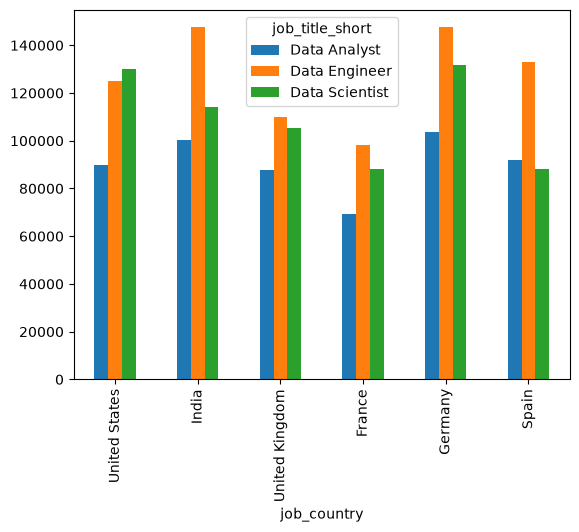

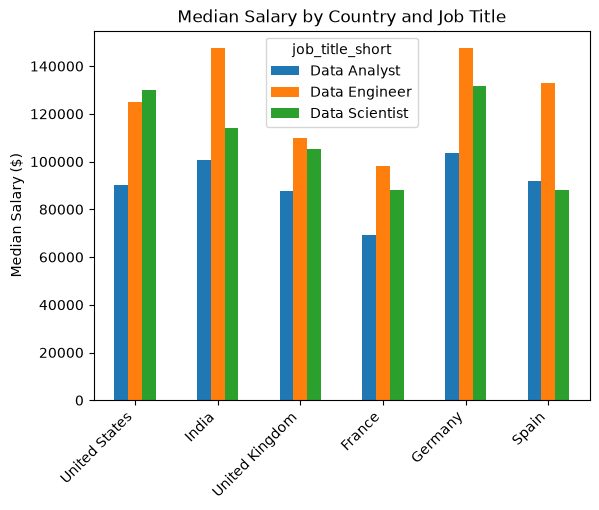

In [16]:
df.pivot_table(values = 'salary_year_avg',index = 'job_title_short',aggfunc = 'median')            #Aggregate to get median yearly salary . Specify columns
                                                                            #Group by cant do it with a single line of code

df.pivot_table(values = 'salary_year_avg',index = 'job_country',columns= 'job_title_short',aggfunc = 'median')       #Full pivot table. USE THIS AS REFERENCE
top_countries = df['job_country'].value_counts().head(6).index
df_job_country_salary = df.pivot_table(
        values = 'salary_year_avg',
        index = 'job_country',
        columns = 'job_title_short',
        aggfunc = 'median'
)
df_job_country_salary = df_job_country_salary.loc[top_countries]
df_job_country_salary                                                                #Gets pivot table for only top 6 countries
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_job_country_salary[job_titles]                                               # Only gets specifically 3 columns
df_job_country_salary[job_titles].plot(kind = 'bar')

df_job_country_salary[job_titles].plot(kind = 'bar')
plt.ylabel('Median Salary ($)')
plt.xlabel('')
plt.title('Median Salary by Country and Job Title')
plt.xticks(rotation=45, ha = 'right')
plt.show()

In [29]:
# Practice Problems

pivot_table = df.pivot_table(index = ['job_country','job_title_short'],aggfunc='count')
pivot_table.head(10)

df.pivot_table(values = 'salary_year_avg',index = 'company_name', aggfunc = ['min','max','mean'])

df_DS = df[df['job_title_short'] == 'Data Scientist'].copy()
pivot_table = df_DS.pivot_table(values = 'salary_year_avg',index = ['job_country','company_name'],aggfunc='median')
pivot_table = pivot_table[pivot_table['salary_year_avg']>200000]
pivot_table.head(10)

salary_year_avg
job_country company_name                       
Argentina   MongoDB                    207500.0
Canada      Course Hero                224000.0
            Mercury                    350000.0
            Secureframe                205000.0
India       GSK                        204381.0
Russia      DevHunt                    250000.0
            SWS                        320000.0
Sudan       ACT                        225000.0
            Airtable                   215500.0
            Algo Capital Group         325000.0

In [ ]:
# Index Management

df.index
df.index.name         # Name of index. Variable holder
df.index.name = 'job_index'
df.head(5)             # Name of column

df.index.dtype            #Integers for the index



#3 index methods

df_usa = df[df['job_country'] =='United States']          #job index doesnt go to one by one. 
df_usa.reset_index(inplace = True)                             #resets the index
df_usa                                                     #New numerical index as a column to go from 1 to whatever number it reaches

df_usa.set_index('job_index', inplace = True)               #drops what we previously had up there. We may lose data some times
df_usa

median_pivot = df.pivot_table(values = 'salary_year_avg',index = 'job_title_short', aggfunc = ['min','max','mean'])
median_pivot
median_pivot.sort_values(by = 'job_title_short', ascending=False)
median_pivot.sort_index(inplace = True)      #Useful When the index doesnt have a column title

In [ ]:
# Exercise: Job Demand across the months


df_US = df[df['job_country'] =='United States'].copy()                      #Filter to US
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')        #Make new column to get the month

df_US_pivot = df_US.pivot_table(index = 'job_posted_month', columns = 'job_title_short',aggfunc='size') 

        #Get the number associated with these months and sort it like that
df_US_pivot.reset_index(inplace =True)
df_US_pivot['month_number'] = pd.to_datetime(df_US_pivot['job_posted_month'],format='%B').dt.month
df_US_pivot['month_number']

df_US_pivot.sort_values('month_number', inplace = True)
df_US_pivot.set_index('job_posted_month',inplace = True)
df_US_pivot.drop(columns = 'month_number',inplace = True)

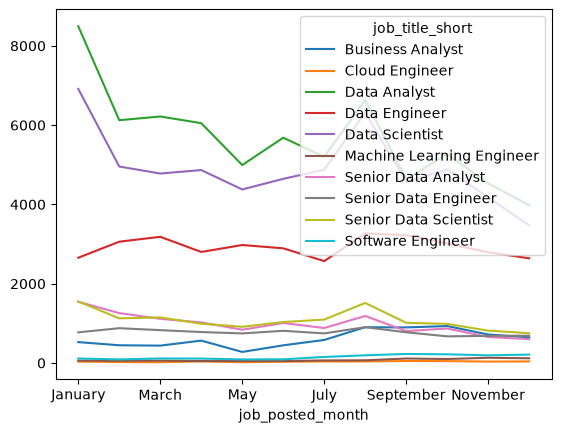

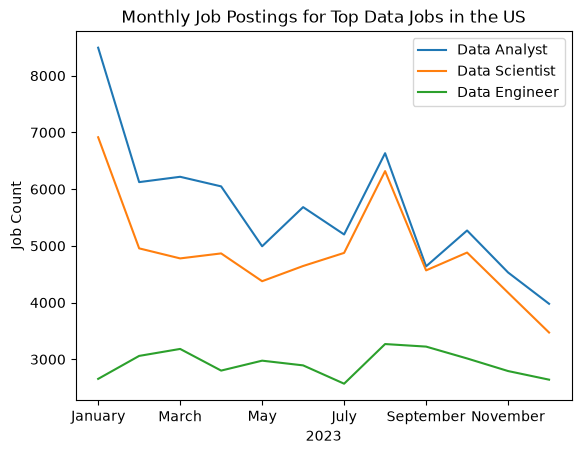

In [65]:
df_US_pivot

#Plotting

df_US_pivot.plot(kind = 'line')

top_3 = df_US['job_title_short'].value_counts().head(3)
top_3 = top_3.index.tolist()

df_US_pivot[top_3].plot(kind = 'line')
plt.title('Monthly Job Postings for Top Data Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()


In [ ]:
# Practice Problems

df.set_index('job_posted_date', inplace=True)
df.head()

df.set_index('job_posted_date', inplace=True) # This is code from the last problem
df.reset_index(drop=True, inplace=True)
df.head()

median_pivot = df.pivot_table(values = 'salary_year_avg',index = 'company_name', aggfunc='median')

KeyError: "None of ['job_posted_date'] are in the columns"

In [ ]:
pivot_table = df.pivot_table(values='salary_year_avg', index='company_name', aggfunc='median')
pivot_table.sort_index(inplace=True, ascending=False)
pivot_table.head()

pivot_table = df.pivot_table(values='salary_year_avg', index='job_title_short', aggfunc='median')
pivot_table.reset_index(inplace=True)
pivot_table.set_index('salary_year_avg',inplace=True)
pivot_table.head()

